# Dataset EDA for Satellite Trail Segmentation

Exploratory analysis of the processed MeerLICHT image subset and the supporting metadata catalogue. All reusable helpers live in `src/evaluation/eda.py` and `src/data/catalog.py`; the notebook keeps only the analysis flow, tables, figures, and interpretation. Figures are written to `bg492/results/figures/` so they sit next to the rest of the run artefacts.

**Scope note.** This notebook is a dataset-characterisation record for the full labelled dataset (`data/Processed`). It supports choices about patching, sparsity, mask quality, metadata coverage, and later preprocessing ablations. It is not the final experiment-results notebook: exact training/test counts and headline metrics should come from the CSD3 patch manifests, threshold sweeps, Hough outputs, and checkpoint summaries.

Sections:
1. Dataset overview tables
2. Full-frame image and mask inspection
3. Patch-level structure, sparsity, and trail examples
4. Mask completeness inspection (visual + quantitative undermasking check)
5. Metadata catalogue summary and visualisations
6. Observation date coverage (contextual; not a temporal trend)


In [1]:
import sys
sys.path.append("..")
from pathlib import Path

import pandas as pd
from IPython.display import display

from src.data.catalog import SatelliteCatalog
from src.evaluation.eda import (
    compute_image_summary_dataframe,
    compute_mask_component_stats,
    compute_observation_date_dataframe,
    compute_patch_dataframe,
    plot_example_satellite_trail_patches,
    plot_image_level_summary,
    plot_mask_inspection_grid,
    plot_mask_thickness_distribution,
    plot_metadata_missing_values,
    plot_observation_date_distribution,
    plot_patch_density_distribution,
    plot_patch_density_heatmap,
    plot_ra_dec_distributions,
    plot_ra_dec_ranges,
    plot_random_image_mask_pairs,
    plot_random_mask_overlays,
    plot_satellite_name_frequency,
    plot_trail_length_distribution,
    summarise_patch_dataframe,
    summarise_patches_by_image,
)
from src.utils.logger import get_logger

In [ ]:
processed_dir = Path("../data/Processed")
catalog_path = Path("../data/Satellites_Catalog_Application.csv")
figure_dir = Path("..") / "results" / "figures"
patch_size = 528
stride = 528
logger = get_logger("dataset_eda")

figure_dir.mkdir(parents=True, exist_ok=True)
processed_dir, catalog_path, figure_dir

## Dataset overview

Build the reusable summaries once, then reuse them throughout the notebook. The main quantities to read from this section are:

- how sparse the binary masks are at both image and 528×528 patch level;
- whether each full frame contributes non-empty patches;
- how much full-frame brightness and contrast vary between images.

The later CSD3 patch builder uses the same 528-pixel grid logic with the same image-level stratified split, so the patch counts here reflect the full labelled dataset.

In [ ]:
catalog = SatelliteCatalog(catalog_path)
image_df = compute_image_summary_dataframe(processed_dir)
patch_df = compute_patch_dataframe(
    root_dir=processed_dir,
    patch_size=patch_size,
    stride=stride,
    logger=logger,
)
patch_summary_df = summarise_patches_by_image(patch_df)
dataset_stats = summarise_patch_dataframe(patch_df)

dataset_summary_df = pd.DataFrame([dataset_stats.to_dict()])
dataset_summary_df["empty_patch_fraction"] = (
    dataset_summary_df["empty_patches"] / dataset_summary_df["total_patches"]
)
dataset_summary_df["non_empty_patch_fraction"] = (
    dataset_summary_df["non_empty_patches"] / dataset_summary_df["total_patches"]
)

display(dataset_summary_df)
display(image_df)
display(patch_summary_df)
display(
    patch_df.loc[:, ["image_name", "y", "x", "positive_pixel_fraction", "is_empty"]]
    .sort_values("positive_pixel_fraction", ascending=False)
    .head(10)
)

### Interpretation

The executed summary shows 178 images and 71,200 non-overlapping 512×512 patches, i.e. 400 patches per 10,560×10,560 frame. Of these, 66,497 patches are empty and 4,703 are non-empty, so 6.61% of patches contain any labelled trail pixels. Across all patch pixels, the positive-pixel fraction is only 0.069%. One image in the dataset has no labelled trail pixels at all.

That sparsity is the central EDA result. It justifies explicit negative sampling and explains why the loss design must handle class imbalance carefully. It also explains why patch-level random splitting would be unsafe: neighbouring patches from the same image are not independent, so the training pipeline later moves to image-level splits.

The image table also shows meaningful frame-to-frame brightness variation: image means range from roughly 78 to 128 on the 8-bit scale, with standard deviations from roughly 23 to 54. This is the empirical motivation for testing full-image normalisation rather than assuming one fixed global scaling is always enough.

## Full-frame image and mask inspection

These random image/mask pairs and overlays are a pairing sanity check. The goal is to confirm that mask files align spatially with their corresponding astronomical image and that the labelled objects visually resemble long linear satellite trails rather than compact sources or broad artefacts.

The figures are qualitative evidence only; the mask-completeness section below provides the more targeted undermasking check.


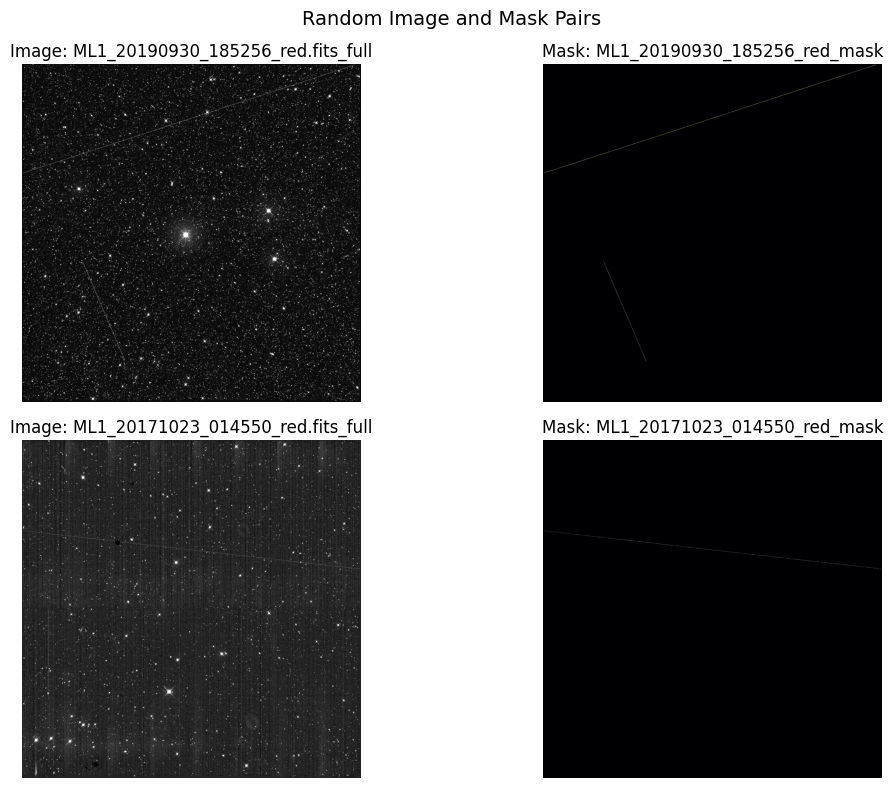

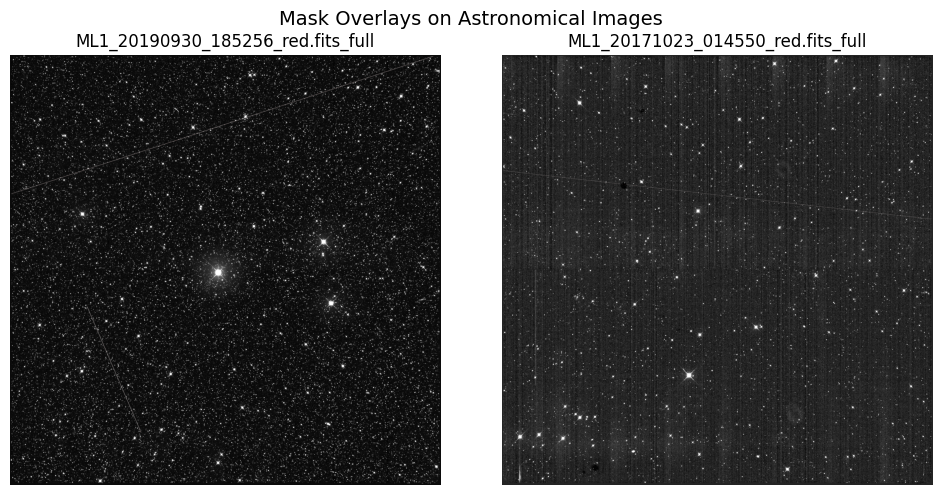

{'random_pairs': PosixPath('../results/figures/eda_random_image_mask_pairs.png'),
 'overlays': PosixPath('../results/figures/eda_random_mask_overlays.png')}

In [4]:
figure_paths = {}
figure_paths["random_pairs"] = plot_random_image_mask_pairs(
    root_dir=processed_dir,
    sample_count=2,
    seed=42,
    output_dir=figure_dir,
    logger=logger,
)
figure_paths["overlays"] = plot_random_mask_overlays(
    root_dir=processed_dir,
    sample_count=2,
    seed=42,
    output_dir=figure_dir,
    logger=logger,
)
figure_paths

### Interpretation

The random full-frame panels provide a quick visual confirmation that image/mask pairing is correct and that masks sit on visually plausible linear features. The overlays should be read as a sanity check before trusting any patch-level statistics: if pairing were wrong here, the downstream patch-density and mask-shape analysis would be meaningless.


## Patch-level structure, sparsity, and trail examples

This section moves from full frames to the exact patch geometry used by the segmentation model: non-overlapping 512×512 crops at stride 512. The plots show where trail-positive patches occur inside each image, how dense the positive pixels are inside those patches, and what the highest-density trail patches look like.

This is the EDA basis for the later 1:3 positive:negative patch sampling design: all positive patches are retained, while the many empty patches are down-sampled to keep training tractable.


In [ ]:
figure_paths["image_level_summary"] = plot_image_level_summary(
    image_df=image_df,
    patch_df=patch_df,
    output_dir=figure_dir,
    logger=logger,
)
figure_paths["density_distribution"] = plot_patch_density_distribution(
    patch_df=patch_df,
    output_dir=figure_dir,
    logger=logger,
)

_top_images = (
    patch_df.groupby("image_name")["is_empty"]
    .apply(lambda s: (~s).sum())
    .nlargest(8)
    .index
)
heatmap_paths = []
for image_name in _top_images:
    heatmap_paths.append(
        plot_patch_density_heatmap(
            patch_df=patch_df,
            image_name=image_name,
            output_dir=figure_dir,
            logger=logger,
        )
    )

figure_paths["heatmaps"] = heatmap_paths
figure_paths["trail_patches"] = plot_example_satellite_trail_patches(
    patch_df=patch_df,
    sample_count=6,
    sort_by_density=True,
    output_dir=figure_dir,
    logger=logger,
)
figure_paths

### Interpretation

The heatmaps and trail-patch panels show that positive pixels are spatially concentrated along narrow tracks. Even the highest-density patches contain only about 8% positive pixels, so pixel-level class imbalance remains severe inside positive patches.

This supports two later choices. First, Dice loss is important because BCE alone is dominated by empty background pixels. Second, reporting precision on a 1:3 sampled test set can be optimistic relative to the paper's natural mostly-empty distribution, which motivates the later paper-parity test set with all negatives retained.

## Mask completeness inspection

The supervisor flagged at the 2026-05-14 meeting that some overlays appear to under-cover the visible trail in the image. This section provides two diagnostics:

- A **shape distribution** over every connected component in the mask set — minor-axis (thickness) and aspect ratio. Long thin masks with very low minor-axis values are candidates for undermasking review.
- A **full-resolution inspection grid** of the densest non-empty patches, rendered at native 512×512 resolution so any trail pixel extending past the mask is visible.

The intended output is a decision for the methodology section: dilate masks, re-annotate worst cases, or accept any residual undercoverage as a known limitation. In the later project plan this was accepted as adequate on the local subset, with residual full-set mask quality recorded as a limitation rather than a code correction.


,component_id,area,major_axis,minor_axis,aspect_ratio
count,24.000000,24.000000,24.000000,24.000000,24.000000
mean,1.291667,69247.875000,10716.064821,11.463405,1032.772350
std,1.041703,39179.578465,3478.059634,4.234595,515.443983
min,1.000000,454.000000,104.018239,5.996231,17.107607
25%,1.000000,42282.750000,9211.154304,8.296518,740.926712
50%,1.000000,60776.000000,12168.835031,11.234464,958.158103
75%,1.000000,94570.500000,12623.803966,13.775405,1272.844594
max,6.000000,145629.000000,16712.746450,20.584272,2035.969577


,image_name,component_id,area,major_axis,minor_axis,aspect_ratio
3,ML1_20171023_014550_red.fits_full.png,1,32509,12208.143987,5.996231,2035.969577
20,ML1_20190822_170731_red.fits_full.png,1,42789,12638.703045,6.447799,1960.157791
12,ML1_20190602_181454_red.fits_full.png,1,47599,13286.954549,6.781440,1959.311780
13,ML1_20190608_180108_red.fits_full.png,1,39296,12540.221365,7.043948,1780.282982
4,ML1_20181227_184754_red.fits_full.png,1,59007,12704.836571,9.322506,1362.813504
2,ML1_20171023_003240_red.fits_full.png,1,74296,12312.948991,9.203774,1337.815239
7,ML1_20190108_192313_red.fits_full.png,1,125940,16712.746450,13.357505,1251.187712
22,ML1_20190930_185256_red.fits_full.png,1,62545,12541.221541,10.406717,1205.108348
8,ML1_20190121_194039_red.fits_full.png,1,70255,13581.655780,11.467257,1184.385763
0,ML1_20170902_022840_red.fits_full.png,1,40764,10712.852917,11.060272,968.588529


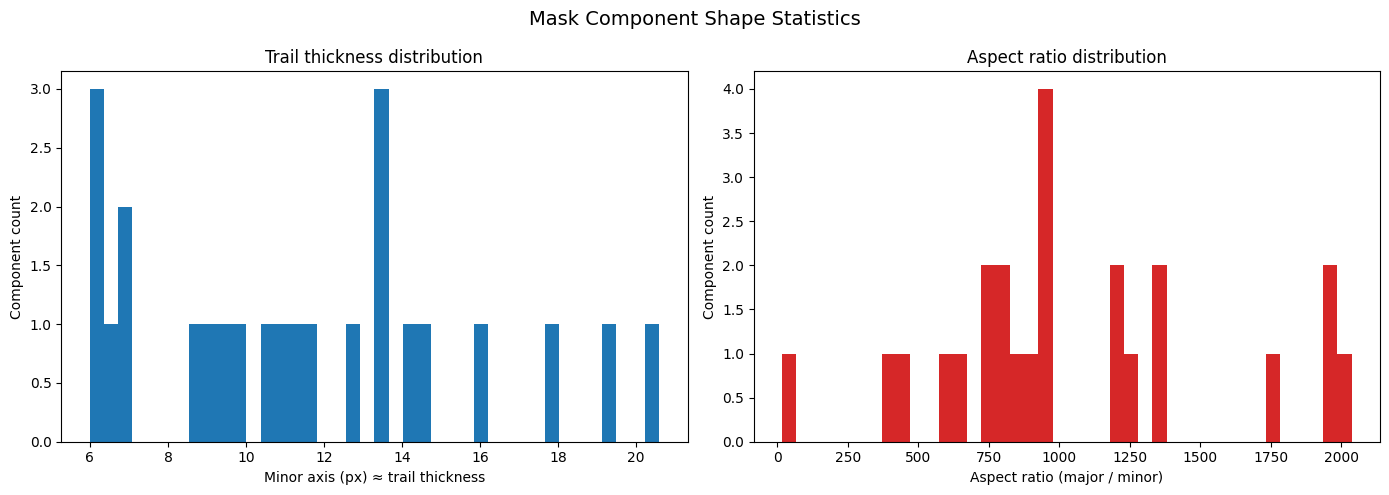

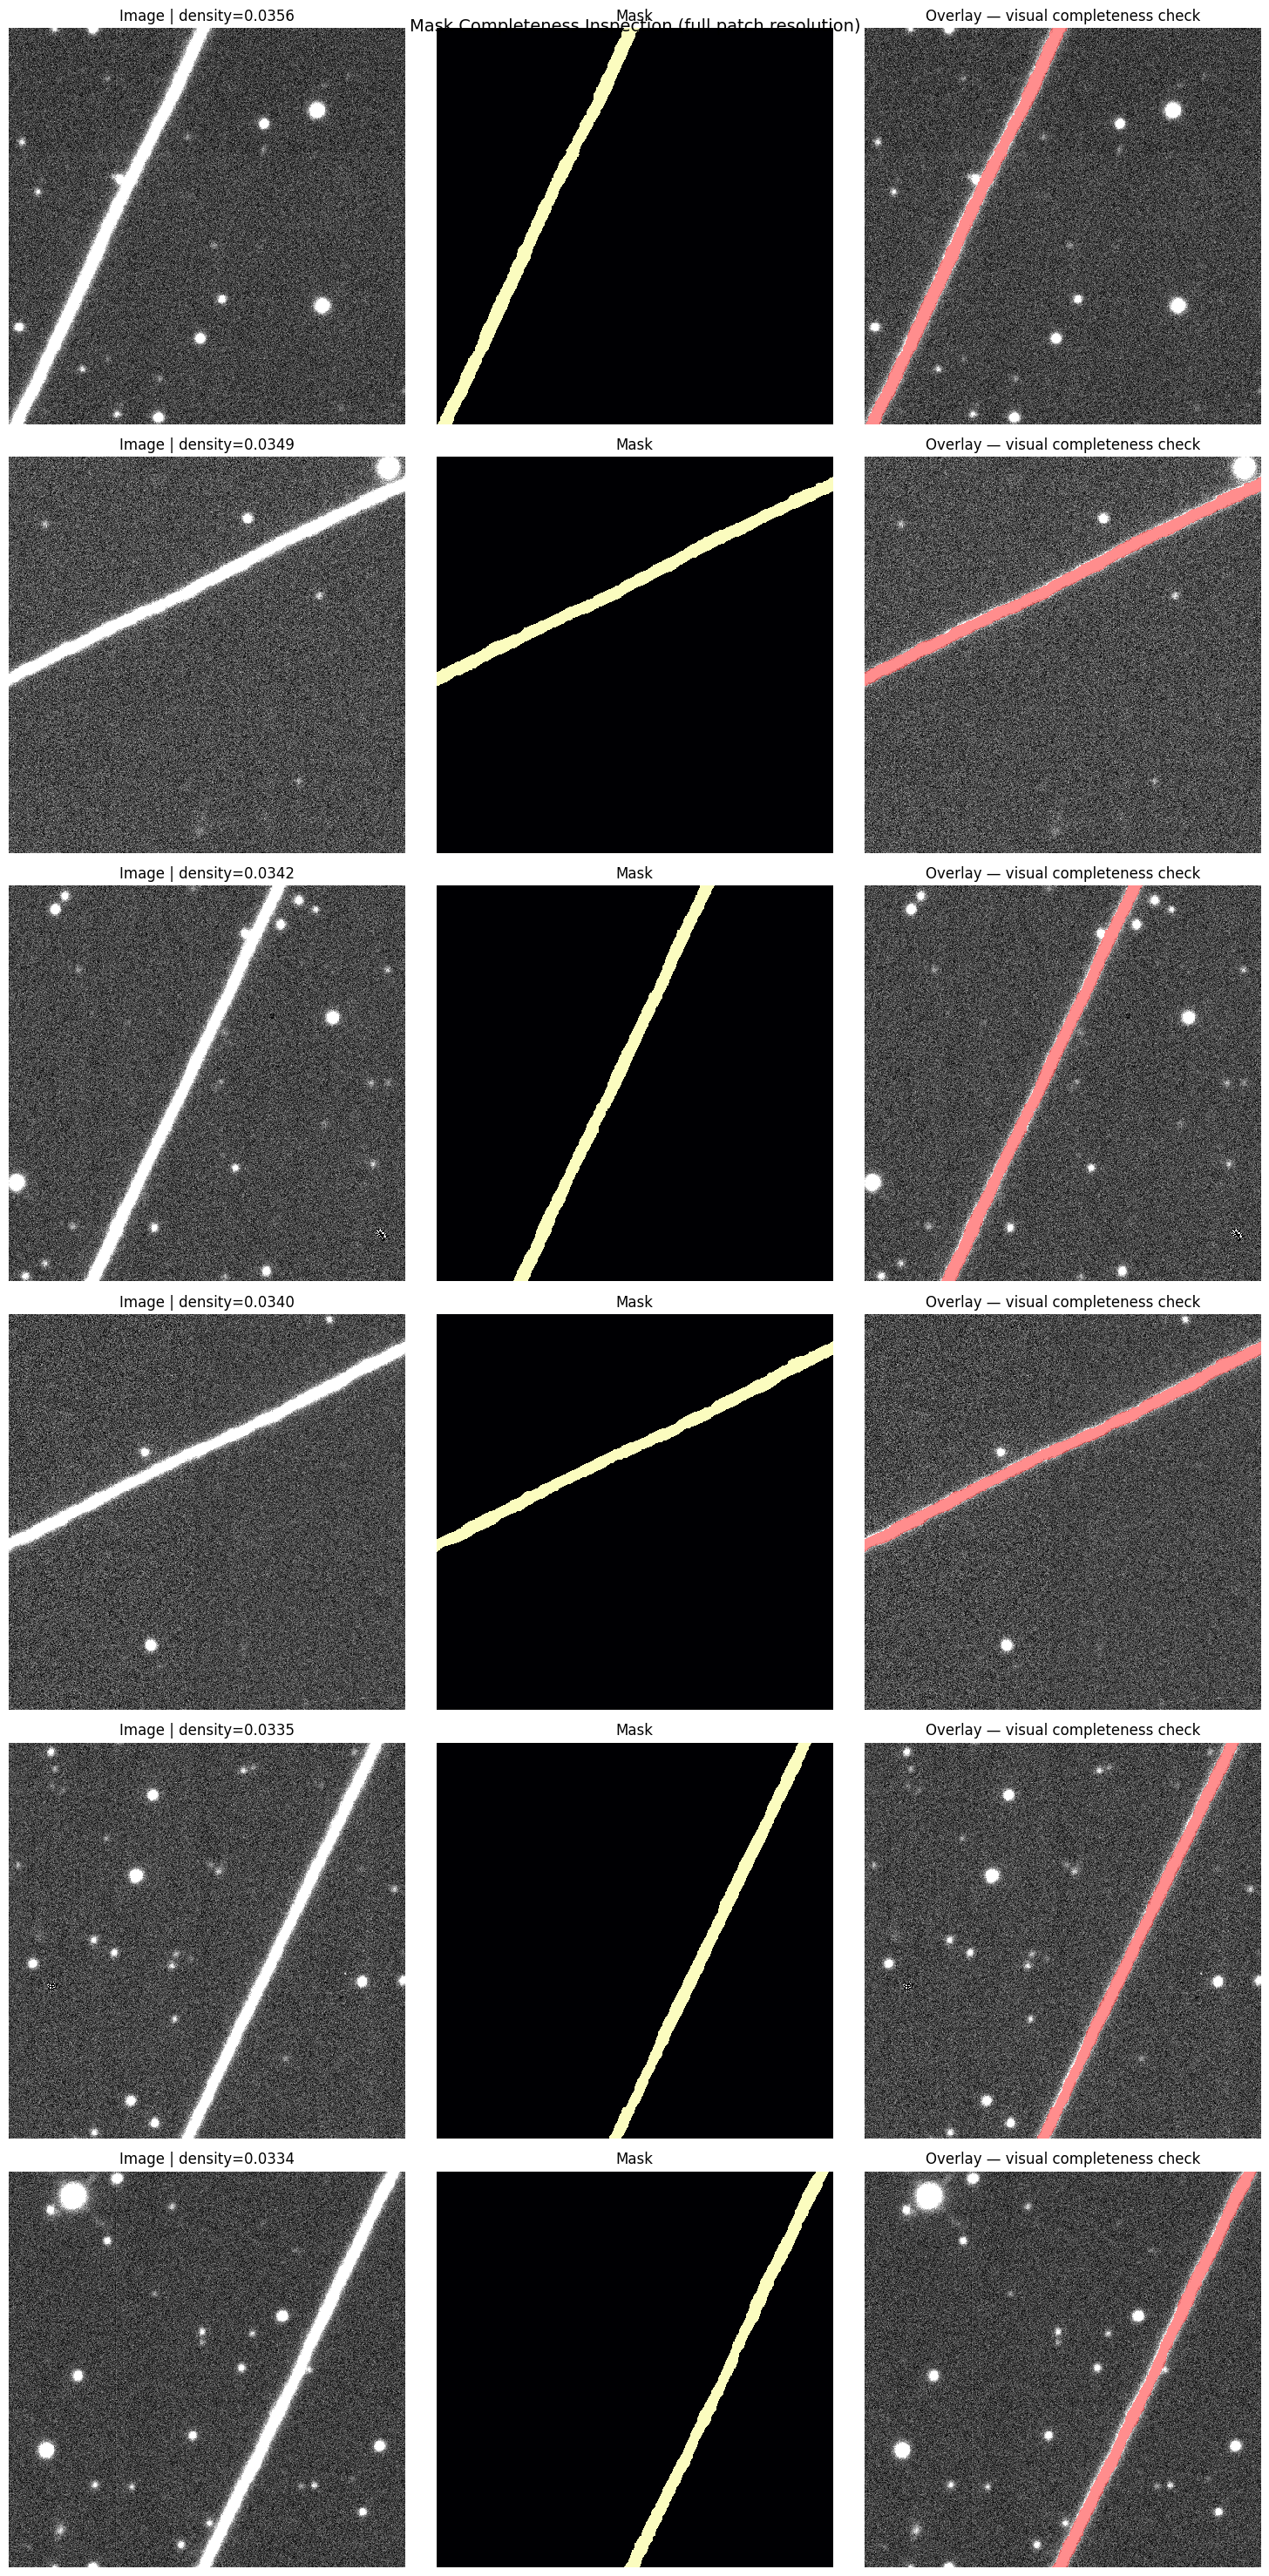

PosixPath('../results/figures/eda_mask_inspection_grid.png')

In [6]:
component_df = compute_mask_component_stats(
    root_dir=processed_dir,
    logger=logger,
)
display(component_df.describe())
display(component_df.sort_values("aspect_ratio", ascending=False).head(10))

figure_paths["mask_thickness"] = plot_mask_thickness_distribution(
    component_df=component_df,
    output_dir=figure_dir,
    logger=logger,
)
figure_paths["mask_inspection_grid"] = plot_mask_inspection_grid(
    patch_df=patch_df,
    n_examples=6,
    output_dir=figure_dir,
    logger=logger,
)
figure_paths["mask_inspection_grid"]

### Interpretation

The component statistics confirm that the masks are long, thin structures: the median minor axis is about 11 px, with a range from roughly 6 px to 21 px, while aspect ratios can exceed 2,000. That morphology is consistent with satellite trails and explains why small mask-width errors can matter visually.

The densest-patch inspection grid is the important qualitative check. If visible trail flux routinely extends outside the mask, dilation or re-annotation would be justified. In the current project notes, the local examples were accepted as adequate, with possible full-set undercoverage retained as a documented limitation.


## Metadata catalogue summary

The metadata catalogue is used here for context, not as the primary training target. The image/mask PNG pairs define the segmentation dataset; the catalogue helps describe the labelled population, satellite-name coverage, apparent trail lengths, and coordinate range.

The key checks are whether numeric fields are complete, how many rows lack satellite names, and whether any single named object dominates the catalogue.


In [7]:
display(pd.DataFrame([catalog.get_metadata_summary()]))
display(catalog.get_missing_value_counts().to_frame(name="missing_values"))
display(catalog.get_numeric_summary())
display(catalog.get_satellite_frequency(top_n=15).to_frame(name="count"))
display(catalog.get_coordinate_dataframe().head(10))
catalog.get_ra_dec_ranges()

,rows,unique_satellites,labelled_rows,missing_satellite_names
0,9107,727,7365,1742


,missing_values
Length,0
Start_RA,0
End_RA,0
Start_DEC,0
End_DEC,0
Satellite_Name,1742


,count,mean,std,min,25%,50%,75%,max
Length,9107.0,1578.360161,36.475200,1440.001389,1564.013587,1589.075517,1602.007803,1639.856091
Start_RA,9107.0,-84.950934,115.812631,-179.799002,-174.730951,-158.413800,-13.257662,179.760714
End_RA,9107.0,-84.845011,115.794318,-179.820016,-174.541890,-158.562887,-13.009536,179.511657
Start_DEC,9107.0,4.479468,5.389840,-14.639185,4.737104,5.288301,5.424328,23.805641
End_DEC,9107.0,4.495492,5.387840,-14.637271,4.760052,5.289370,5.428857,23.842867


,count
Satellite_Name,
EXPRESS AM-44,118
EXPRESS AM-8,116
WGS 9 (USA 275),107
TELSTAR 12V,105
EUTE 8 WEST B,98
EUTE 5W B,87
MUOS 3,81
LUCH (OLYMP),81
ABS 3A,75


,Satellite_Name,Start_RA,End_RA,Start_DEC,End_DEC,Length
0,EUTE KONNECT,53.041755,53.293008,5.161228,5.162105,1603.011229
1,RADUGA 13,-145.454891,-145.702932,-8.377361,-8.349888,1580.387611
2,HELLAS-SAT 3,-92.709252,-92.455671,5.175605,5.175372,1617.001237
3,ARABSAT 1DR (TELSTAR 3A),153.915035,153.685850,11.409914,11.474425,1495.448093
4,EUTE 2-F2,-27.164865,-26.926716,-6.826902,-6.780034,1549.515085
5,ECHOSTAR 4,-155.784092,-156.025323,7.594085,7.640930,1561.695553
6,RADUGA 1-7,135.081540,134.824851,18.831438,18.849860,1564.233039
7,EUTE 7B (EUTE 3D),165.648527,165.899215,5.354097,5.353666,1593.001255
8,YNET 5B,-174.838254,-174.587095,5.840280,5.839289,1598.005006
9,AL YAH 3,63.563962,63.812343,4.975975,4.976988,1579.007916


{'ra': (-179.82001571554076, 179.76071448252685),
 'dec': (-14.639184524940848, 23.842866806088107)}

### Interpretation

The catalogue summary reports complete numeric fields for `Length`, RA, and Dec, but incomplete satellite-name labels. Trail lengths are tightly clustered around roughly 1,580 pixels in the catalogue output, while RA/Dec spans are broad. These values help describe the annotation source and sky coverage; they do not alter the segmentation target, which remains the binary mask PNG.


## Metadata catalogue visualisations

These figures convert the catalogue tables into thesis-ready context: the most frequent named satellites, trail-length distribution, missing-value pattern, and sky-coordinate coverage. They should be used to describe the labelled subset, not to make survey-rate or temporal-incidence claims.


In [ ]:
figure_paths["satellite_frequency"] = plot_satellite_name_frequency(
    catalog=catalog,
    top_n=15,
    output_dir=figure_dir,
    logger=logger,
)
figure_paths["trail_length_distribution"] = plot_trail_length_distribution(
    catalog=catalog,
    output_dir=figure_dir,
    logger=logger,
)
figure_paths["metadata_missing_values"] = plot_metadata_missing_values(
    catalog=catalog,
    output_dir=figure_dir,
    logger=logger,
)
figure_paths["ra_dec_distributions"] = plot_ra_dec_distributions(
    catalog=catalog,
    output_dir=figure_dir,
    logger=logger,
)
figure_paths["ra_dec_ranges"] = plot_ra_dec_ranges(
    catalog=catalog,
    output_dir=figure_dir,
    logger=logger,
)
figure_paths

### Interpretation

The catalogue contains 9,107 rows, 727 unique named satellites, and 7,365 rows with a satellite name; 1,742 rows lack `Satellite_Name`. The numeric trail and coordinate columns are complete in this file, so length and RA/Dec summaries are safe to report as catalogue context.

The top named satellites each account for only tens to low hundreds of entries. This suggests the catalogue is not dominated by a single object, but the missing-name count is large enough that named-satellite frequency should be treated as descriptive rather than exhaustive.


## Observation date coverage

Dates are parsed from the `ML1_YYYYMMDD_HHMMSS` filename prefix. The labelled subset is not a uniform sample over time (it was selected for annotation, not as a survey snapshot) and we have no exposure-time metadata, so this figure is **strictly contextual** — it shows the temporal span of the training data and is not used to support any trend claim about trail incidence.


In [ ]:
date_df = compute_observation_date_dataframe(processed_dir)
display(date_df.head())
display(
    date_df["observation_year"]
    .value_counts()
    .sort_index()
    .to_frame(name="image_count")
)

figure_paths["observation_dates"] = plot_observation_date_distribution(
    date_df=date_df,
    output_dir=figure_dir,
    logger=logger,
)
figure_paths["observation_dates"]

### Interpretation

The full dataset spans seven calendar years: 4 images from 2017, 3 from 2018, 27 from 2019, 14 from 2020, 26 from 2021, 97 from 2022, and 7 from 2023. The 2022 skew (97 of 178 images) reflects annotation selection rather than a temporal trend in satellite incidence. This is useful provenance for the labelled dataset, not evidence that trails became more common after 2021. Exposure-time and survey-denominator information is not available in the PNG-only dataset.

## EDA conclusions used downstream

This notebook supports the following methodology choices and limitations:

- **Patch sparsity:** the dataset is overwhelmingly empty at the patch level, so a patch-sampling strategy is necessary for efficient U-Net training. The final CSD3 builder keeps all positive patches and samples negatives.
- **Image-level splitting:** patches from the same source frame share background, seeing, trail morphology, and annotation context. This motivates image-level train/val/test splitting rather than patch-level random splitting.
- **Patch geometry:** 528×528 non-overlapping patches produce a regular 20×20 grid on 10,560×10,560 images and match the released ASTA model input shape. This removes the earlier 512×512 border-gap deviation.
- **Normalisation:** full-frame means and standard deviations vary visibly across the dataset (means 78–128, std 23–54 on the 8-bit scale), so the later `fixed` / `per_image` / `full_image` normalisation ablation is methodologically justified.
- **Mask quality:** the masks are thin, high-aspect-ratio structures consistent with satellite trails. The inspection supports accepting the annotations as adequate, while recording possible residual undercoverage as a limitation.
- **Metadata scope:** catalogue fields provide useful context for satellite identity, trail length, and coordinate coverage, but the segmentation target is the PNG mask, not the catalogue row.

This notebook does **not** provide final model performance evidence. Final precision, recall, Dice, FNR, threshold choice, Hough post-processing, parity-test results, and confidence intervals should all be cited from CSD3 outputs and result JSONs.